## Import

In [ ]:
import numpy as np
import pandas as pd
from datasets import load_dataset, Value, Sequence, ClassLabel
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

## SuperGLUE Tasks List

In [ ]:
SUPERGLUE_TASKS = [
    "boolq", "cb", "copa", "multirc", "record",
    "rte", "wic", "wsc", "axb", "axg"
]

## Nested feature extraction

In [ ]:
def get_text_fields(features, prefix=""):
    text_fields = []
    for name, feat in features.items():
        full = f"{prefix}.{name}" if prefix else name

        if isinstance(feat, Value) and feat.dtype == "string":
            text_fields.append(full)

        elif isinstance(feat, dict):
            text_fields.extend(get_text_fields(feat, prefix=full))

        elif isinstance(feat, Sequence) and isinstance(feat.feature, dict):
            text_fields.extend(get_text_fields(feat.feature, prefix=full))

    return text_fields


def get_nested(example, field):
    parts = field.split(".")
    val = example
    for p in parts:
        val = val[p]
    return val

## EDA Functions

In [ ]:
def label_info(dataset):
    for name, feat in dataset.features.items():
        if isinstance(feat, ClassLabel):
            labels = dataset[name]
            counter = Counter(labels)
            total = len(labels)
            dist = {feat.names[k]: v for k, v in counter.items()}
            pct = {k: f"{v/total:.2%}" for k, v in dist.items()}
            return name, dist, pct
    return None, None, None


def text_length_stats(dataset, text_fields, max_samples=5000):
    stats = {}
    n = min(len(dataset), max_samples)

    for field in text_fields:
        lengths = []
        for i in range(n):
            text = get_nested(dataset[i], field)
            if isinstance(text, str):
                lengths.append(len(text.split()))

        if lengths:
            arr = np.array(lengths)
            stats[field] = {
                "mean": float(arr.mean()),
                "std": float(arr.std()),
                "min": int(arr.min()),
                "max": int(arr.max()),
                "p50": float(np.percentile(arr, 50)),
                "p90": float(np.percentile(arr, 90)),
            }
    return stats


def dataset_to_dataframe(dataset, text_fields):
    rows = []
    for ex in dataset:
        row = {}
        for f in text_fields:
            row[f] = get_nested(ex, f)
        for name, feat in dataset.features.items():
            if isinstance(feat, ClassLabel):
                row[name] = feat.names[ex[name]]
        rows.append(row)
    return pd.DataFrame(rows)

In [ ]:
def run_superglue_eda():
    all_stats = {}

    for task in SUPERGLUE_TASKS:
        print(f"\n=== {task.upper()} ===")
        ds = load_dataset("super_glue", task)

        task_summary = {}

        for split in ds.keys():
            dsplit = ds[split]
            print(f"\n--- Split: {split} ---")
            print(f"Examples: {len(dsplit)}")

            text_fields = get_text_fields(dsplit.features)
            print("Text fields:", text_fields)

            label_col, dist, pct = label_info(dsplit)
            if label_col:
                print("Label distribution:", dist)

            length_stats = text_length_stats(dsplit, text_fields)

            df = dataset_to_dataframe(dsplit, text_fields)
            df.to_csv(f"{task}_{split}.csv", index=False)

            task_summary[split] = {
                "num_examples": len(dsplit),
                "text_fields": text_fields,
                "label_distribution": dist,
                "length_stats": length_stats,
            }

        all_stats[task] = task_summary

    return all_stats


if __name__ == "__main__":
    stats = run_superglue_eda()
    pd.to_pickle(stats, "superglue_eda_summary.pkl")


=== BOOLQ ===

--- Split: train ---
Examples: 9427
Text fields: ['question', 'passage']
Label distribution: {'True': 5874, 'False': 3553}

--- Split: validation ---
Examples: 3270
Text fields: ['question', 'passage']
Label distribution: {'False': 1237, 'True': 2033}

--- Split: test ---
Examples: 3245
Text fields: ['question', 'passage']
Label distribution: {'True': 3245}

=== CB ===

--- Split: train ---
Examples: 250
Text fields: ['premise', 'hypothesis']
Label distribution: {'entailment': 115, 'contradiction': 119, 'neutral': 16}

--- Split: validation ---
Examples: 56
Text fields: ['premise', 'hypothesis']
Label distribution: {'contradiction': 28, 'neutral': 5, 'entailment': 23}

--- Split: test ---
Examples: 250
Text fields: ['premise', 'hypothesis']
Label distribution: {'neutral': 250}

=== COPA ===

--- Split: train ---
Examples: 400
Text fields: ['premise', 'choice1', 'choice2', 'question']
Label distribution: {'choice1': 195, 'choice2': 205}

--- Split: validation ---
Example

In [ ]:
sns.set(style="whitegrid")

def flatten_dict(d, parent_key="", sep="."):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)

def load_superglue_as_dfs(tasks=SUPERGLUE_TASKS):
    all_dfs = {}
    for task in tasks:
        ds = load_dataset("super_glue", task)
        task_dfs = {}
        for split in ds.keys():
            flat = [flatten_dict(x) for x in ds[split]]
            df = pd.DataFrame(flat)

            # decode ClassLabel columns if present
            for name, feat in ds[split].features.items():
                if isinstance(feat, ClassLabel):
                    df[name] = df[name].map(lambda i: feat.names[i])

            task_dfs[split] = df
        all_dfs[task] = task_dfs
    return all_dfs

all_dfs = load_superglue_as_dfs()

## Seaborn / Matplotlib Dashboard

In [ ]:
def detect_text_columns(df, min_string_ratio=0.5, sample_size=50):
    text_cols = []
    for col in df.columns:
        sample = df[col].dropna().head(sample_size)
        if len(sample) == 0:
            continue
        ratio = sample.apply(lambda x: isinstance(x, str)).mean()
        if ratio >= min_string_ratio:
            text_cols.append(col)
    return text_cols

def plot_label_distribution(df, task, split):
    if "label" not in df.columns:
        return
    plt.figure(figsize=(5,4))
    df["label"].value_counts().plot(kind="bar")
    plt.title(f"{task} – {split} – label distribution")
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

def plot_text_length_histograms(df, task, split):
    text_cols = detect_text_columns(df)
    if not text_cols:
        print(f"[{task} – {split}] No text columns detected.")
        return

    for col in text_cols:
        lengths = df[col].astype(str).str.split().str.len()
        plt.figure(figsize=(5,4))
        sns.histplot(lengths, bins=50)
        plt.title(f"{task} – {split} – {col} length")
        plt.xlabel("Word count")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

def plot_dataset_sizes(all_dfs):
    rows = []
    for task, splits in all_dfs.items():
        for split, df in splits.items():
            rows.append({"task": task, "split": split, "n": len(df)})
    sizes = pd.DataFrame(rows)

    plt.figure(figsize=(10,5))
    sns.barplot(data=sizes, x="task", y="n", hue="split")
    plt.title("SuperGLUE – dataset sizes by task and split")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Run the dashboard

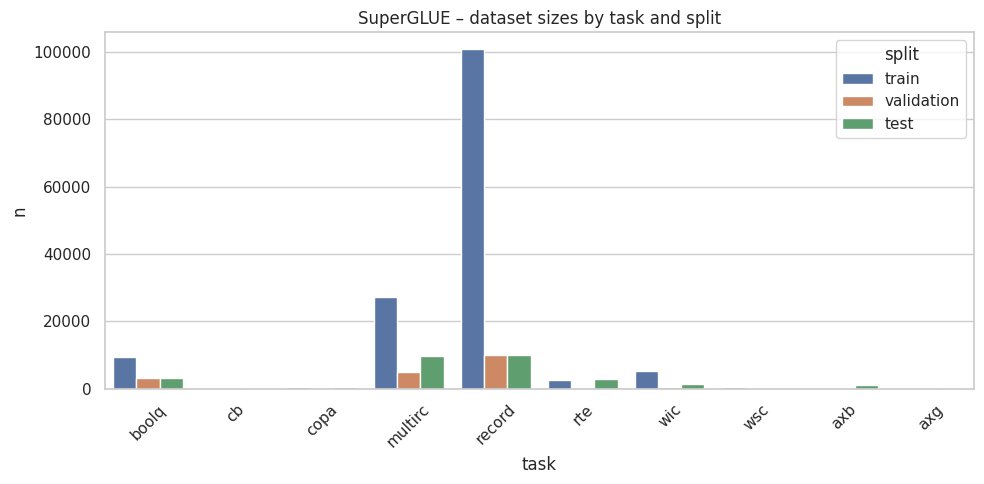


=== BOOLQ ===
boolq – train – shape: (9427, 4)


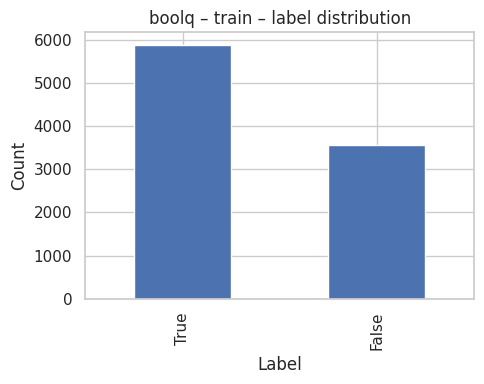

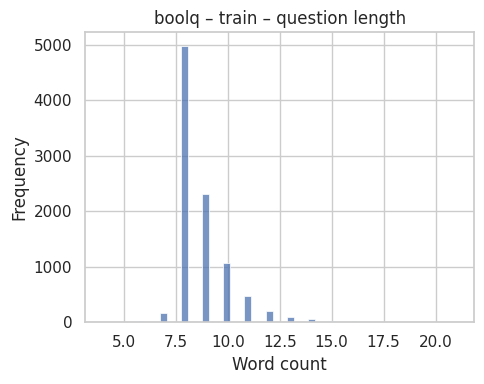

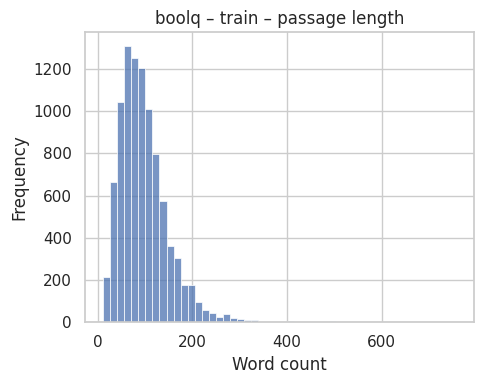

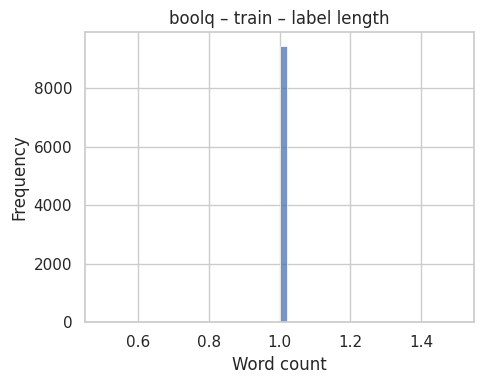

boolq – validation – shape: (3270, 4)


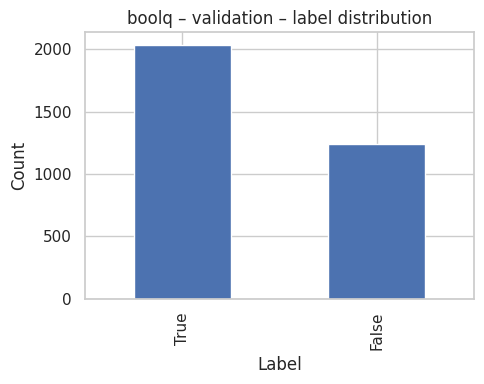

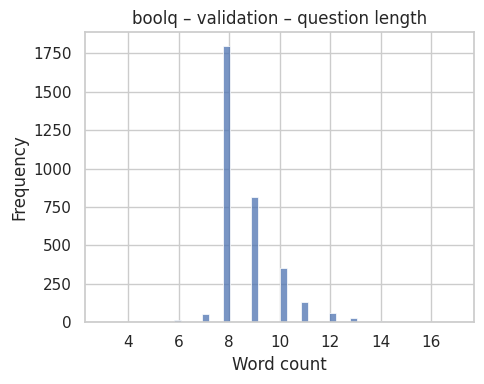

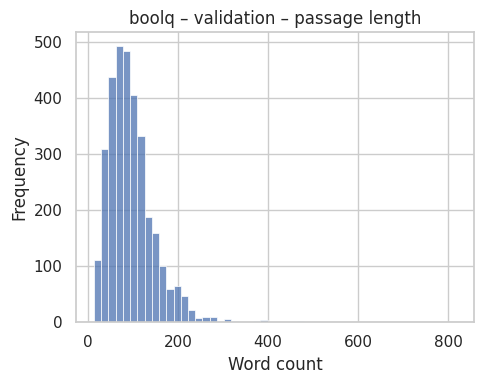

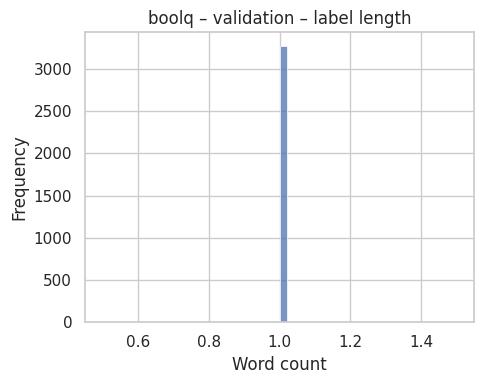

boolq – test – shape: (3245, 4)


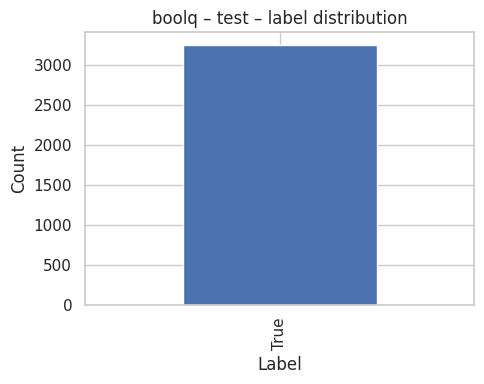

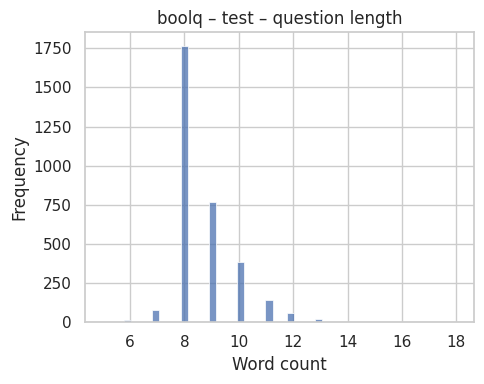

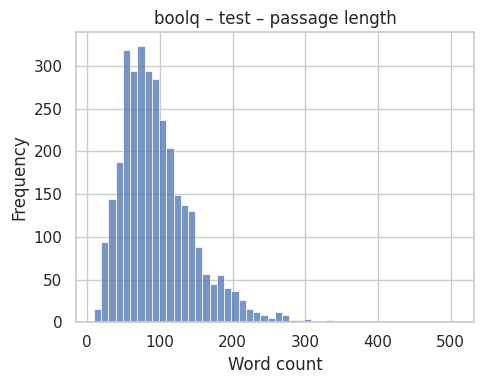

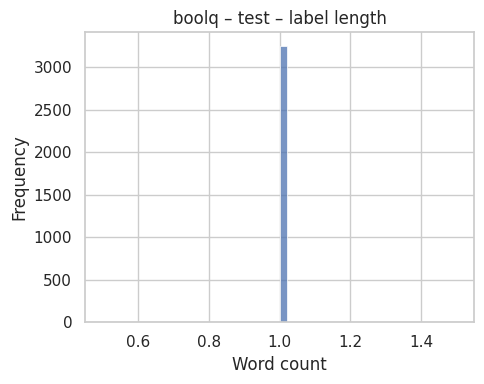


=== CB ===
cb – train – shape: (250, 4)


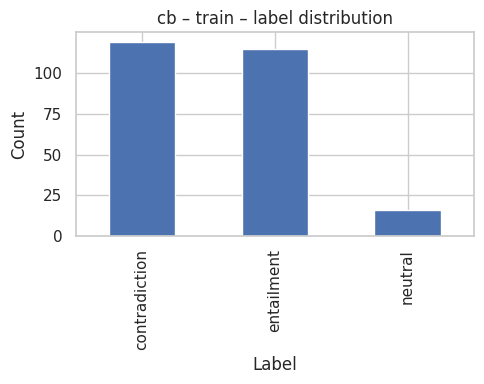

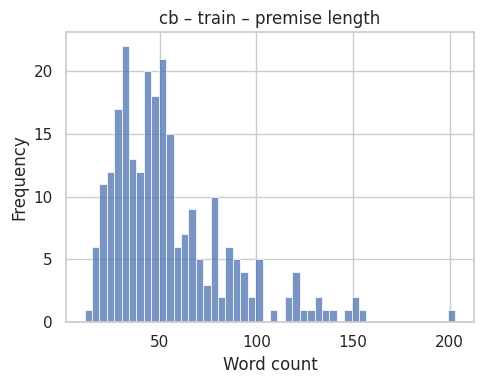

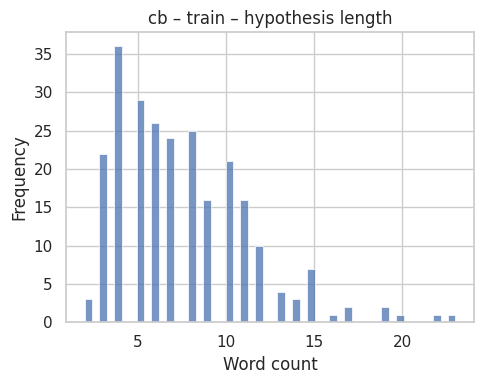

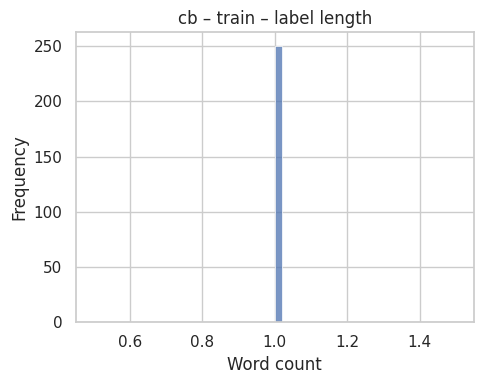

cb – validation – shape: (56, 4)


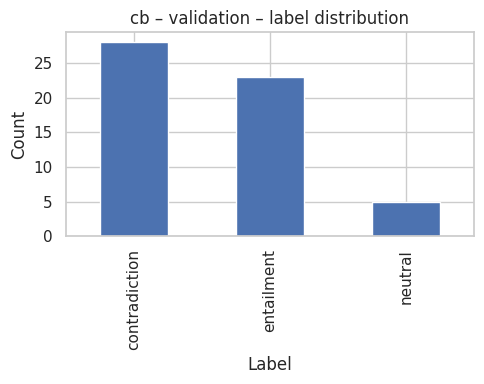

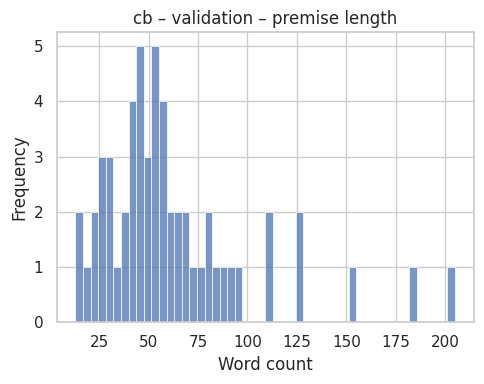

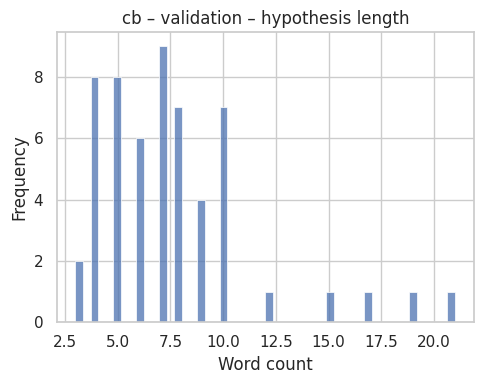

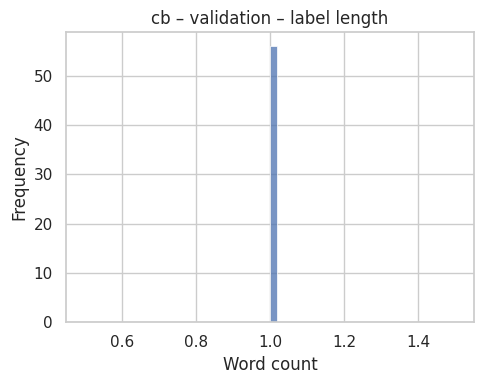

cb – test – shape: (250, 4)


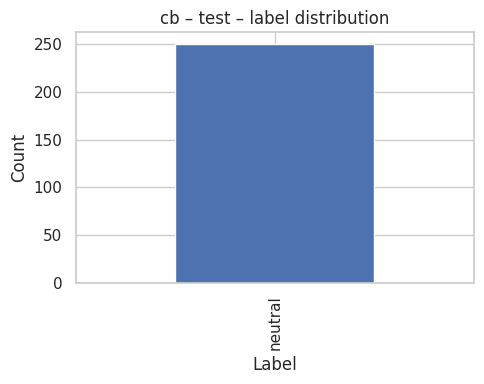

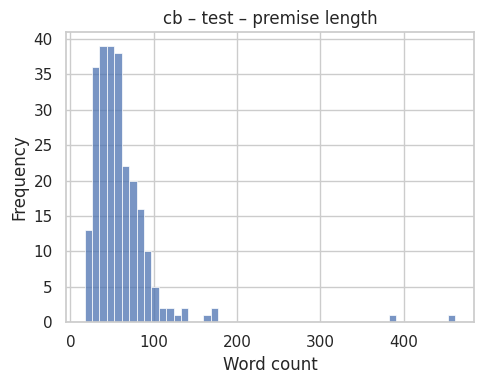

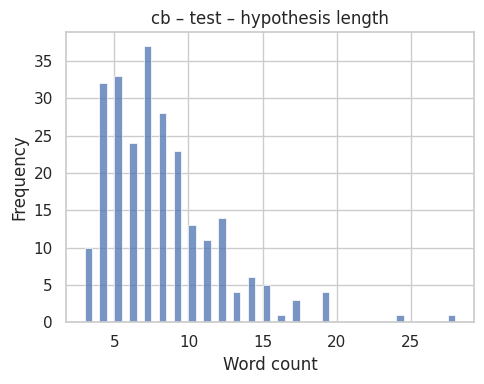

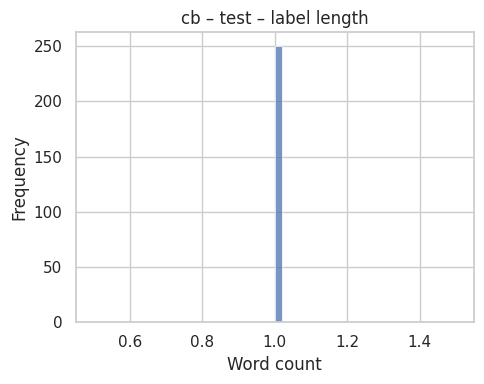


=== COPA ===
copa – train – shape: (400, 6)


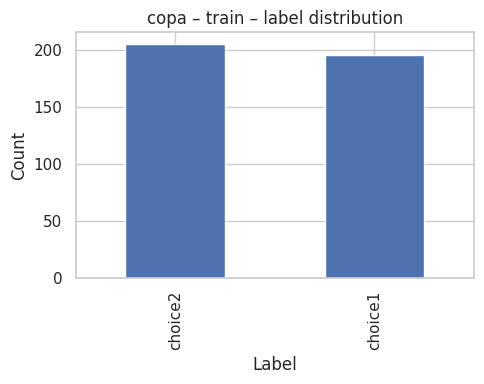

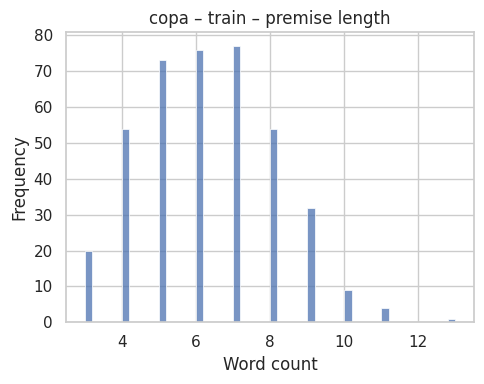

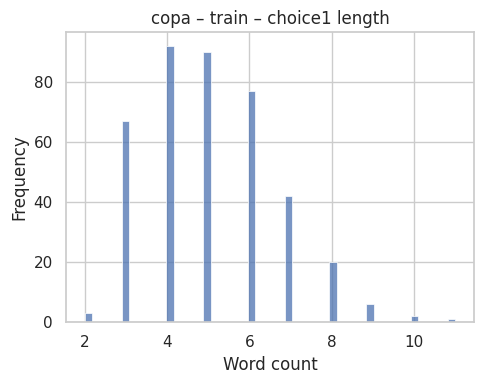

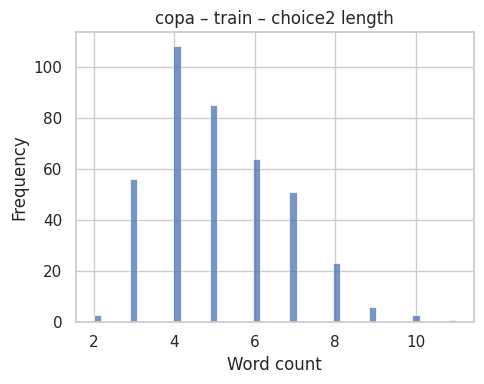

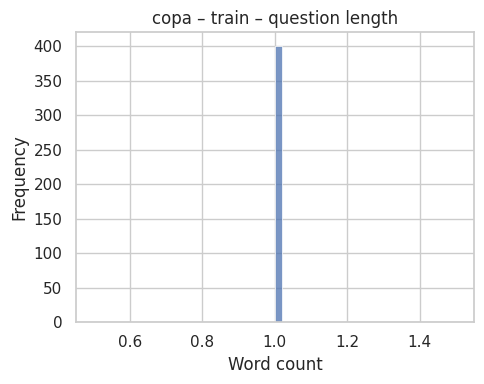

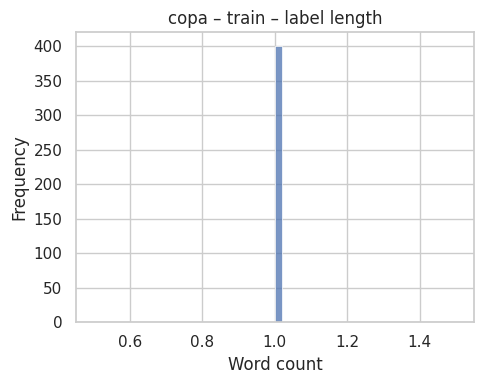

copa – validation – shape: (100, 6)


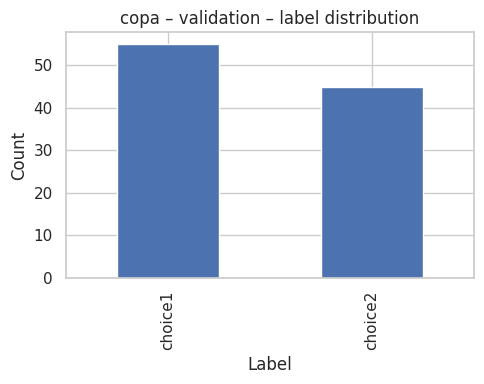

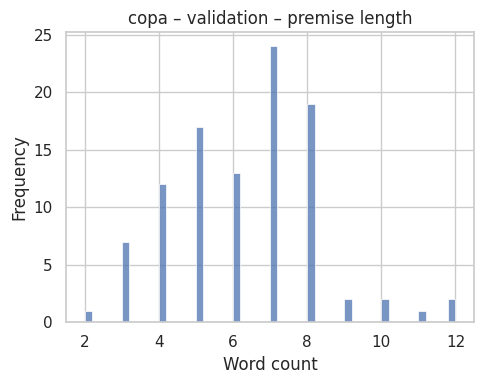

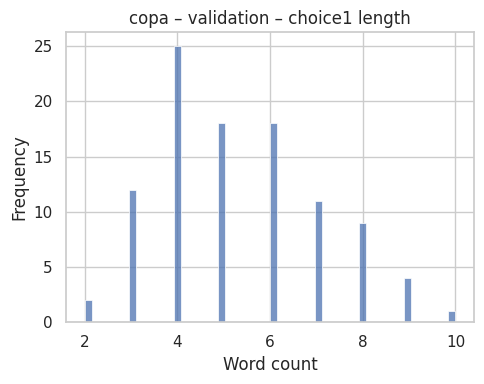

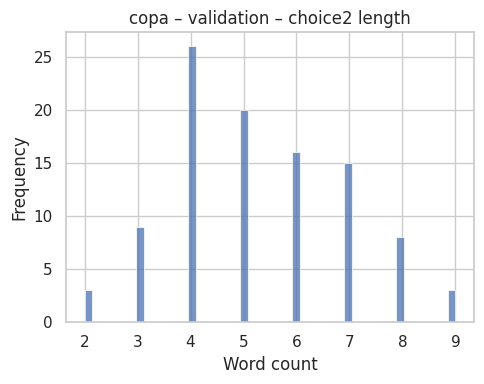

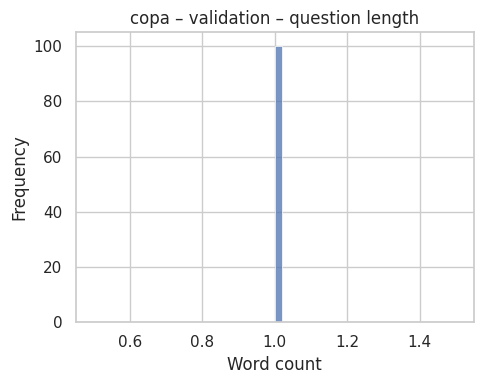

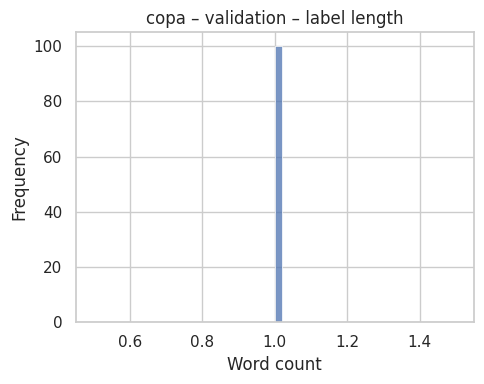

copa – test – shape: (500, 6)


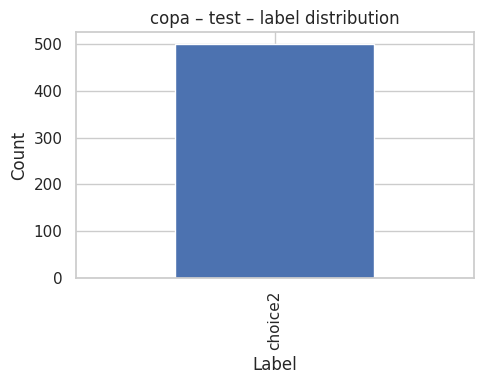

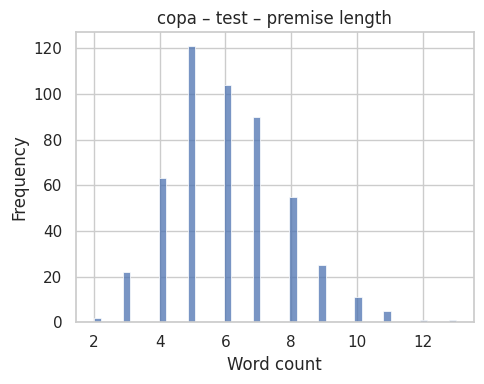

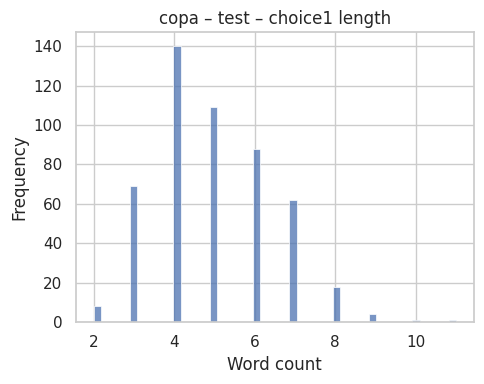

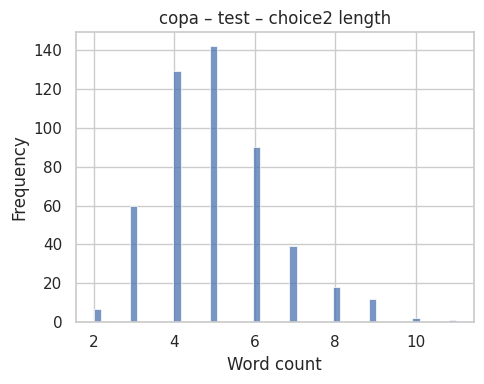

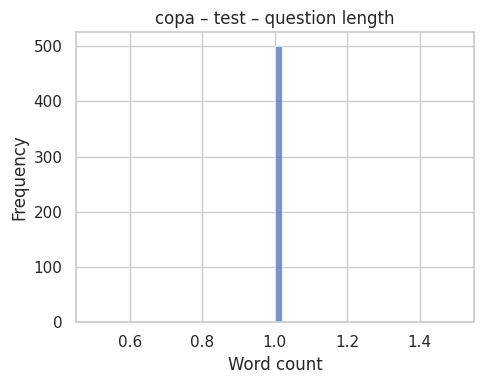

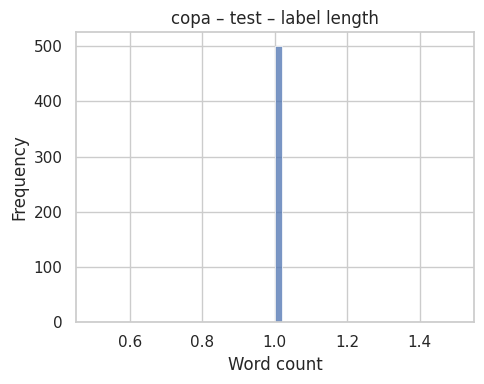


=== MULTIRC ===
multirc – train – shape: (27243, 7)


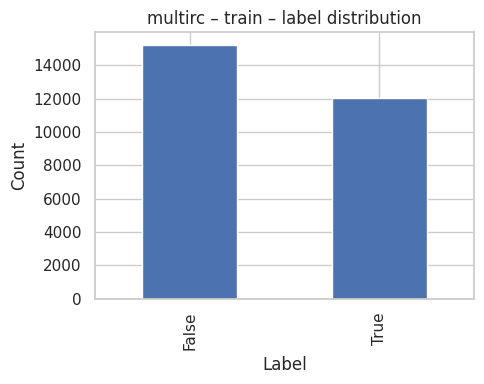

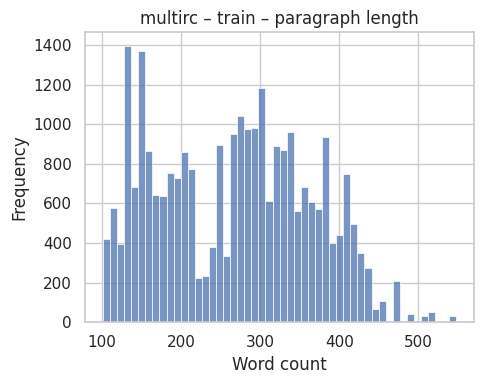

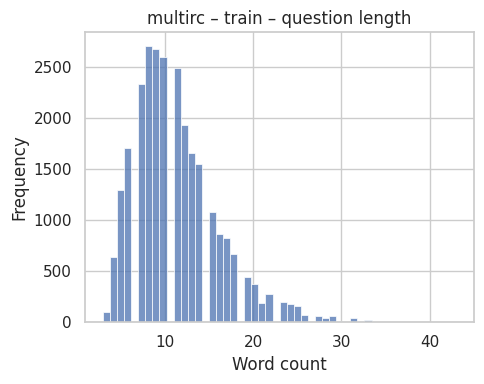

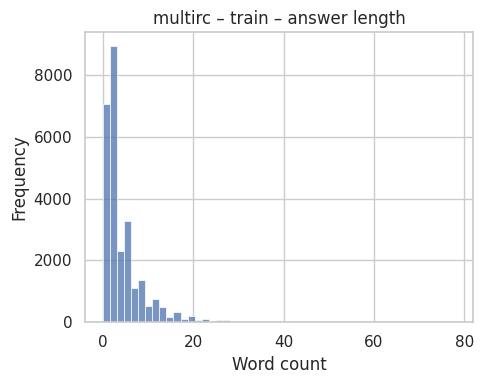

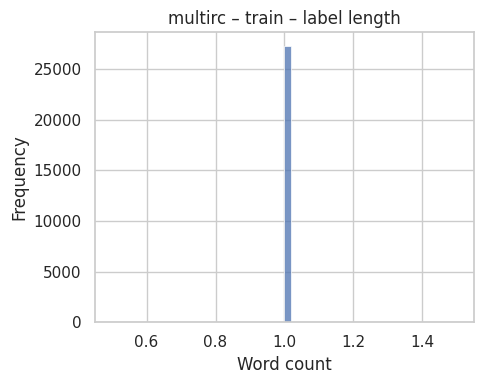

multirc – validation – shape: (4848, 7)


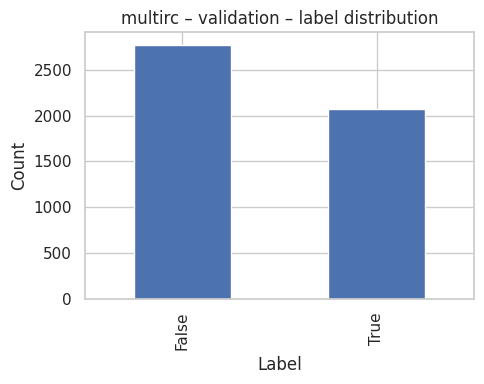

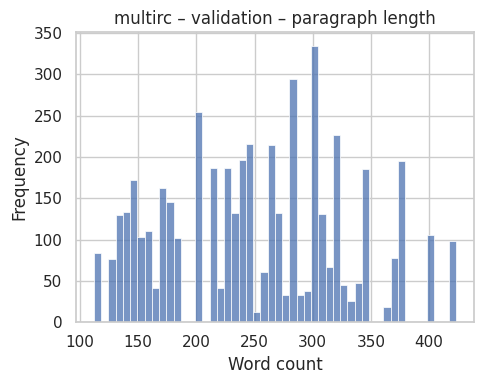

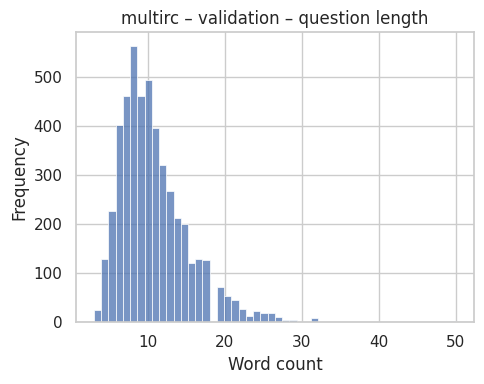

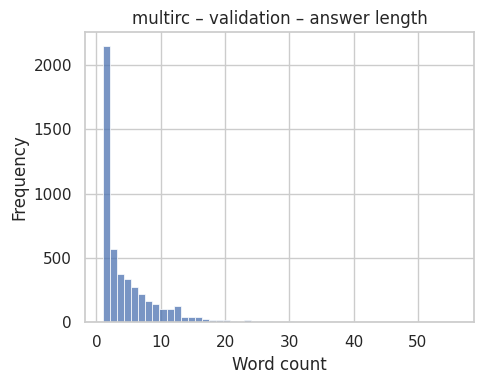

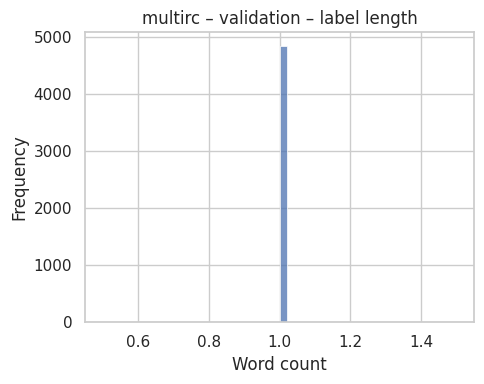

multirc – test – shape: (9693, 7)


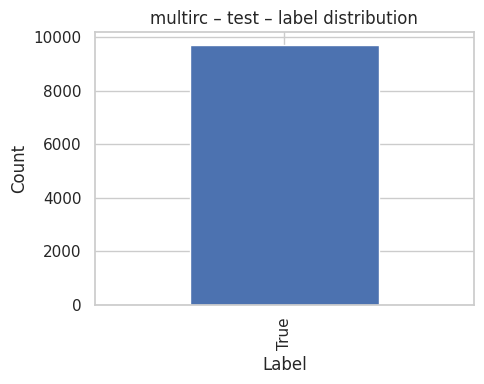

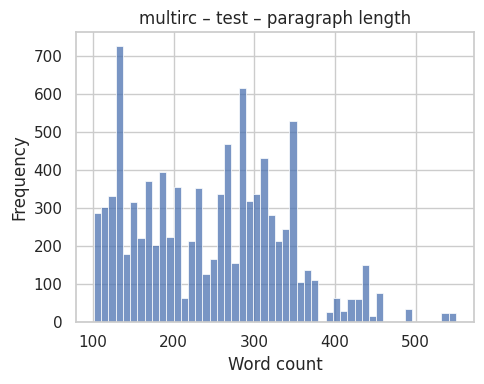

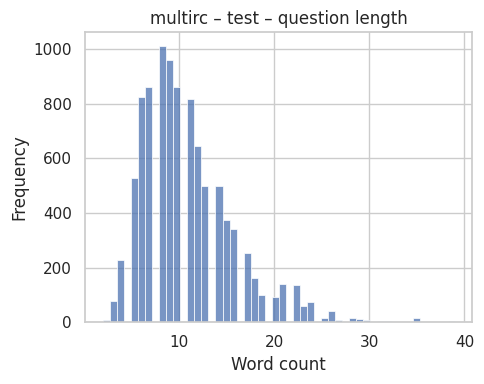

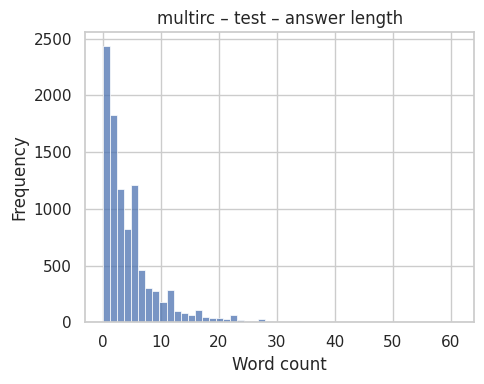

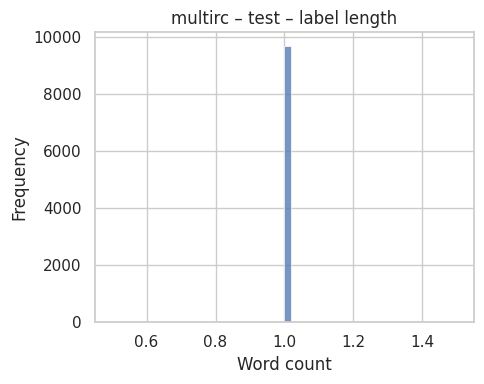


=== RECORD ===
record – train – shape: (100730, 9)


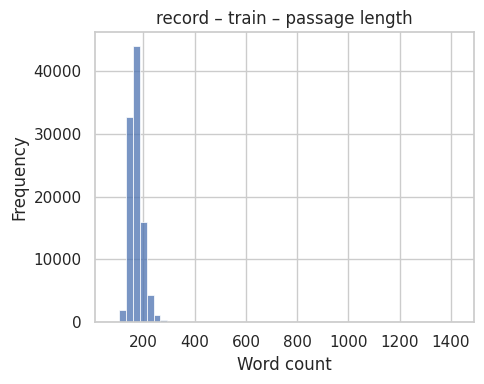

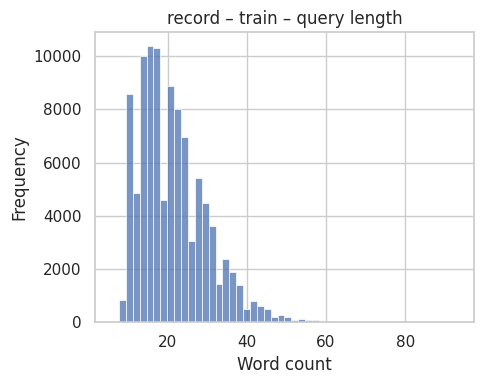

record – validation – shape: (10000, 9)


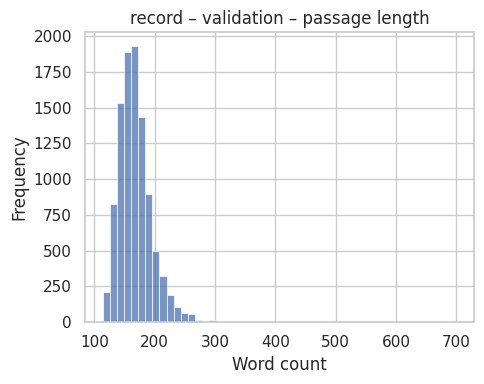

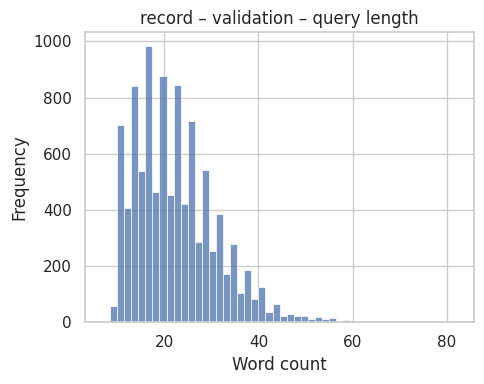

record – test – shape: (10000, 9)


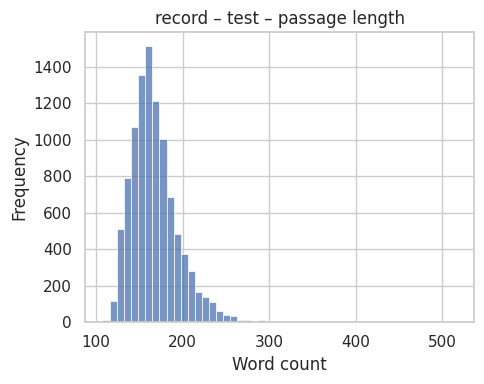

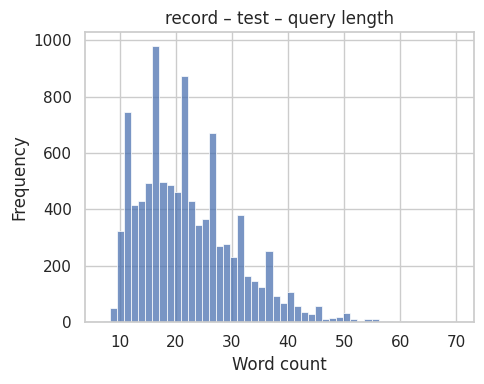


=== RTE ===
rte – train – shape: (2490, 4)


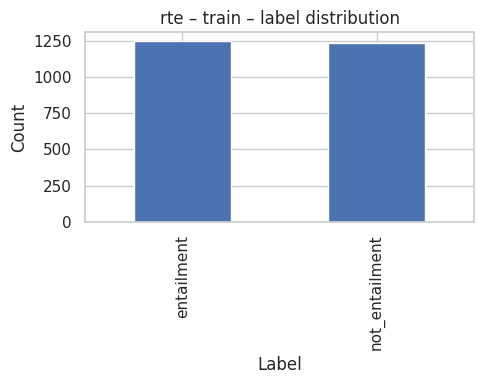

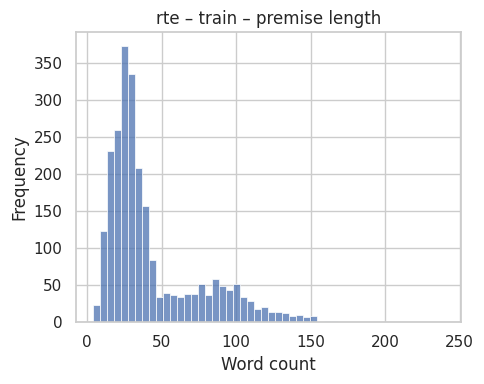

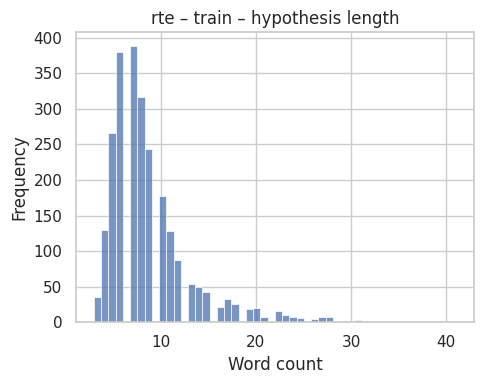

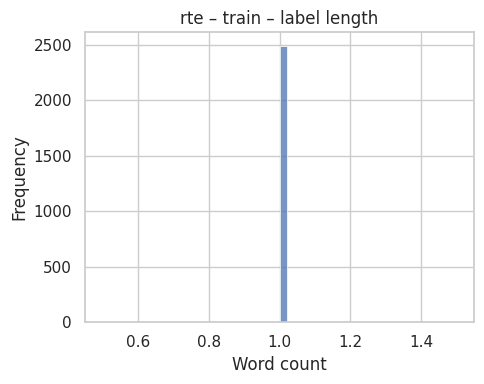

rte – validation – shape: (277, 4)


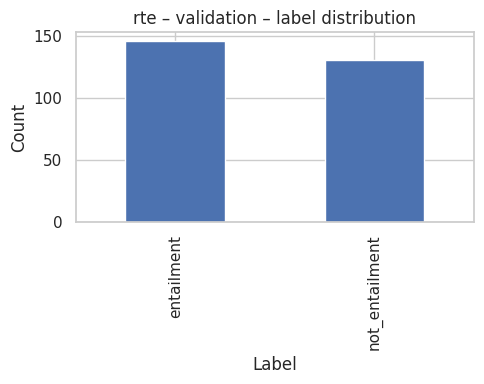

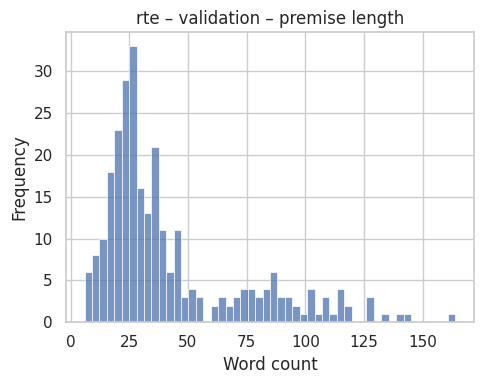

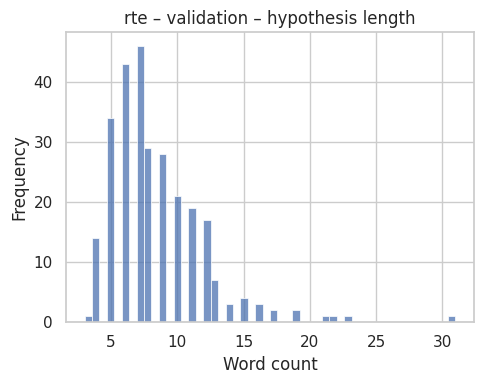

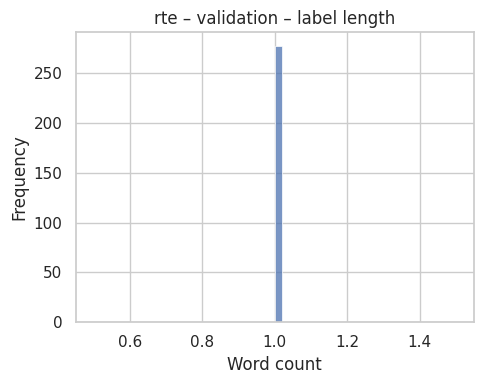

rte – test – shape: (3000, 4)


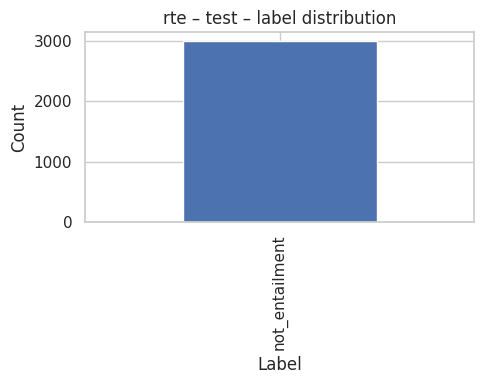

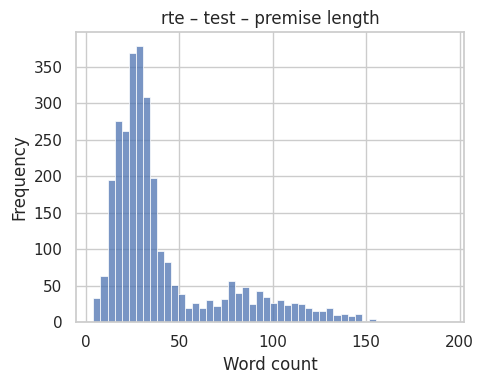

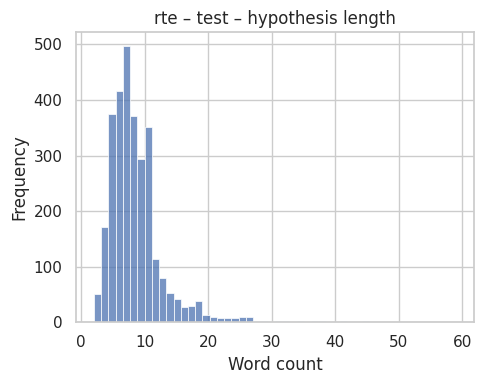

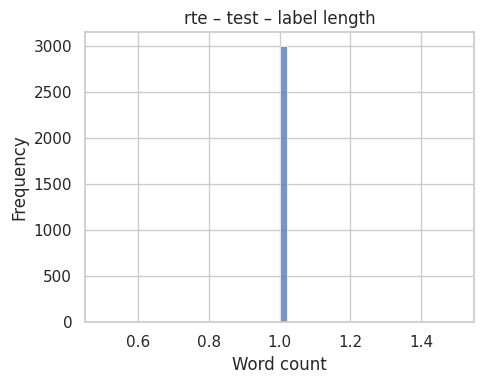


=== WIC ===
wic – train – shape: (5428, 9)


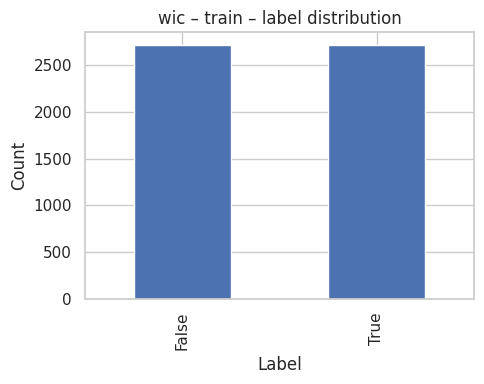

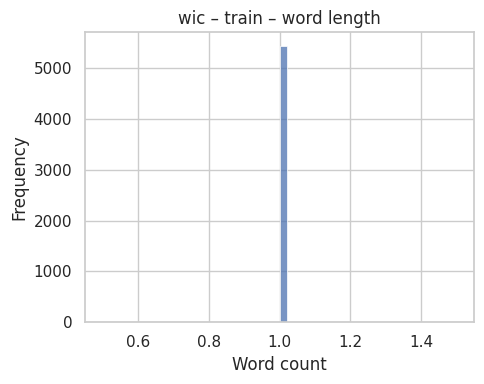

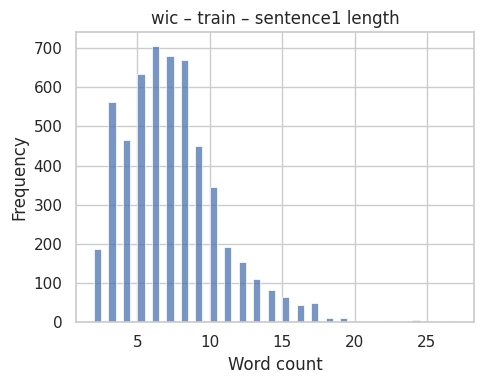

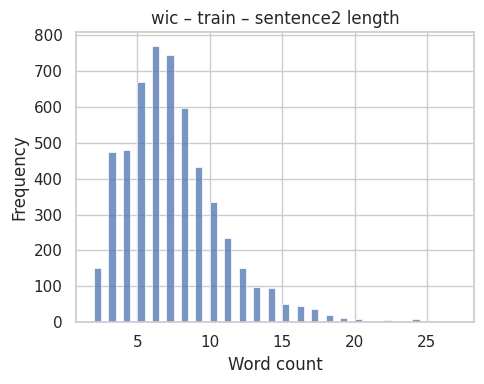

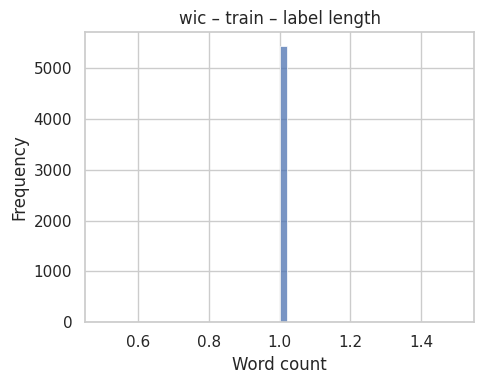

wic – validation – shape: (638, 9)


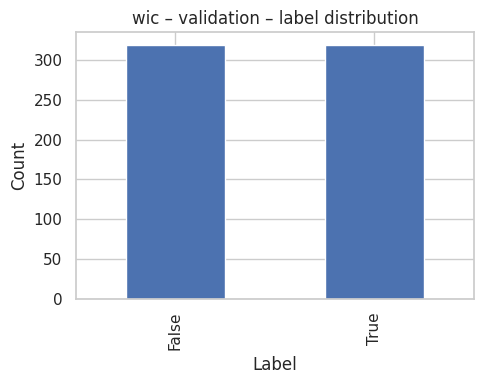

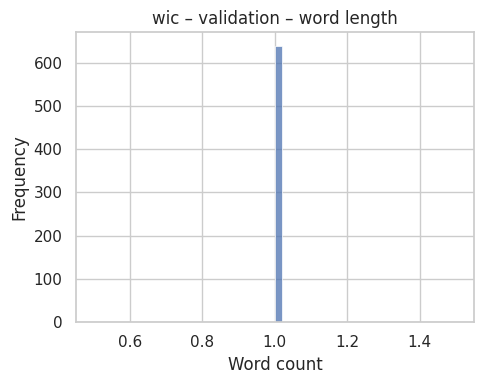

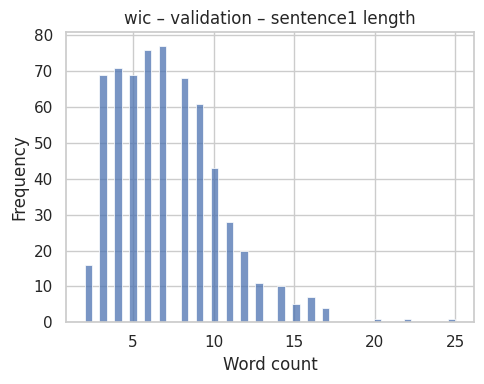

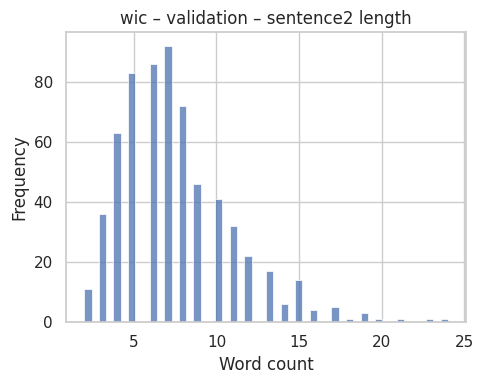

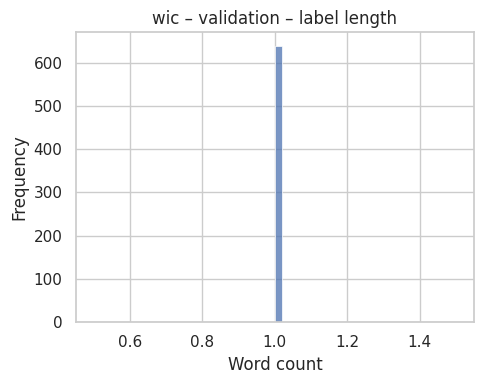

wic – test – shape: (1400, 9)


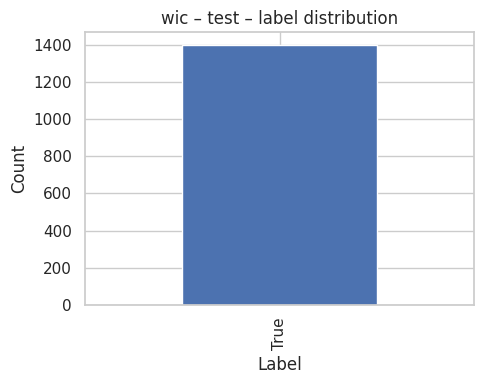

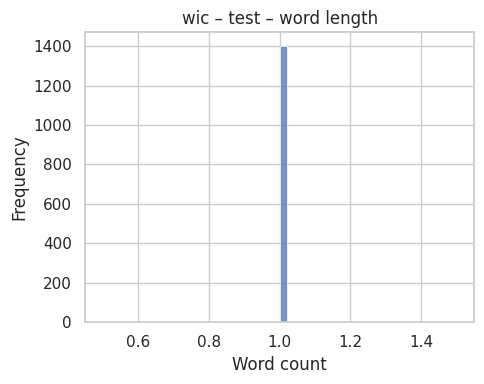

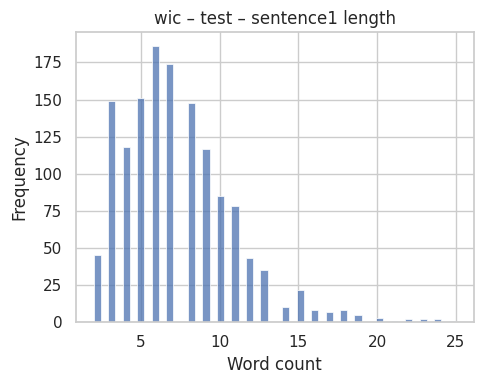

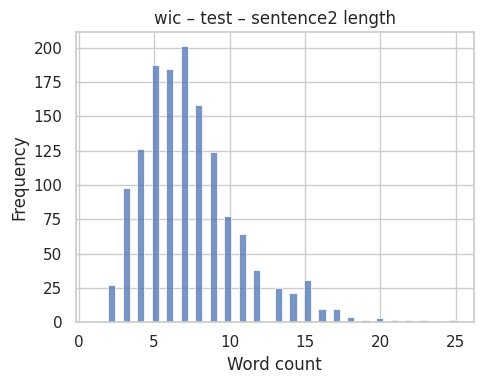

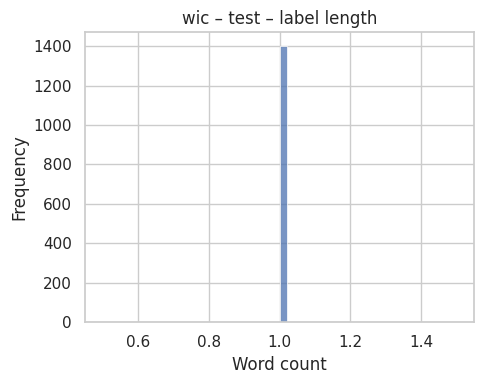


=== WSC ===
wsc – train – shape: (554, 7)


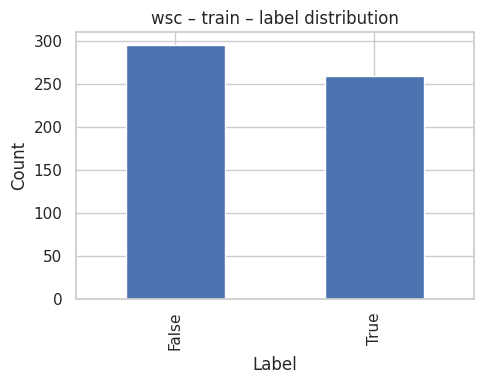

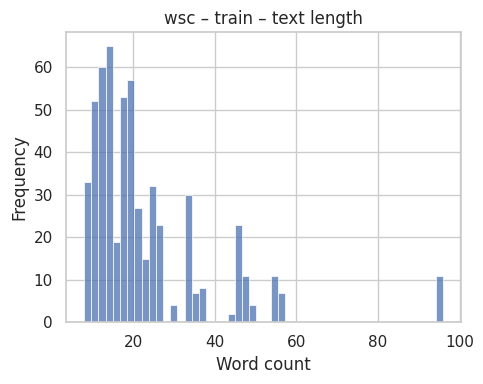

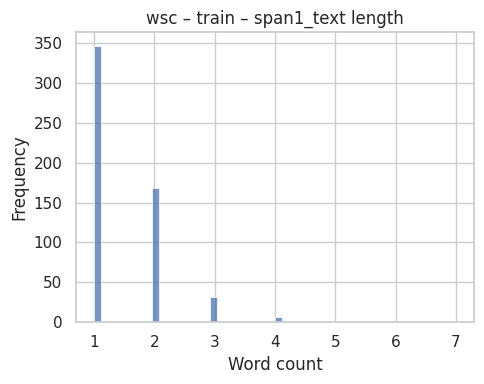

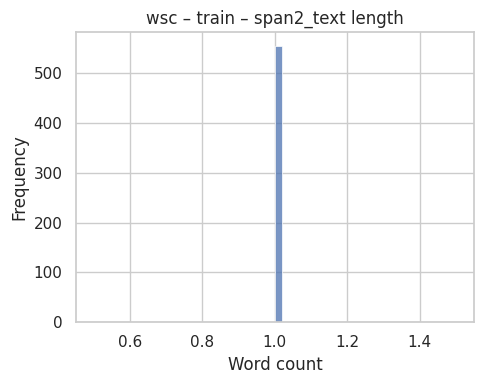

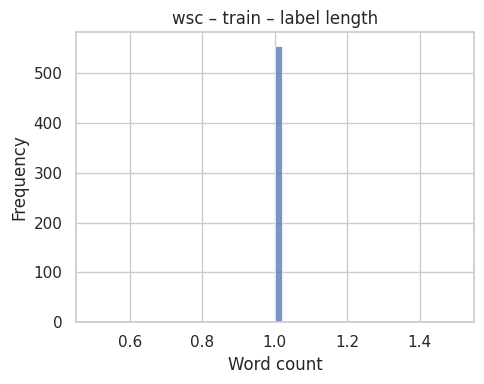

wsc – validation – shape: (104, 7)


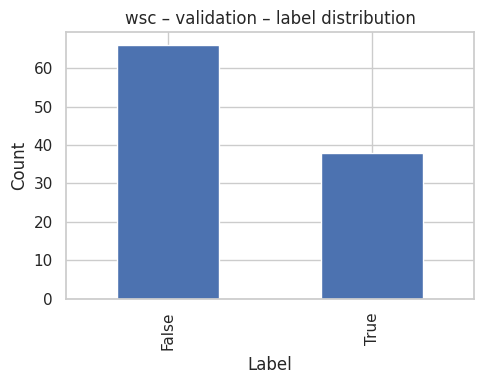

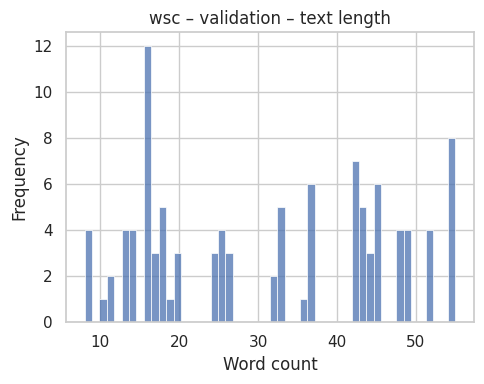

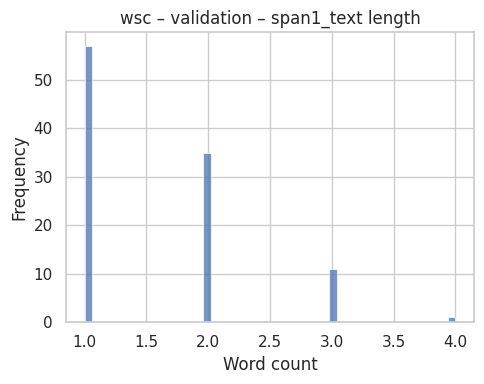

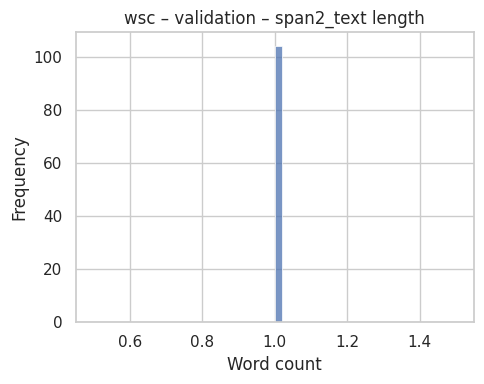

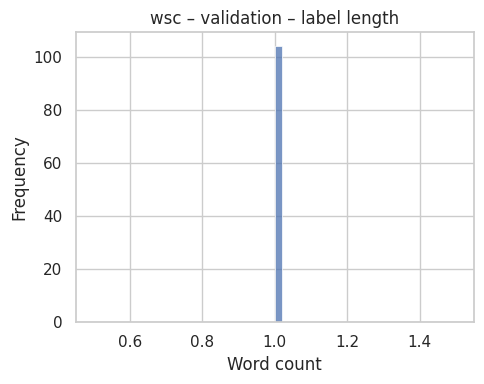

wsc – test – shape: (146, 7)


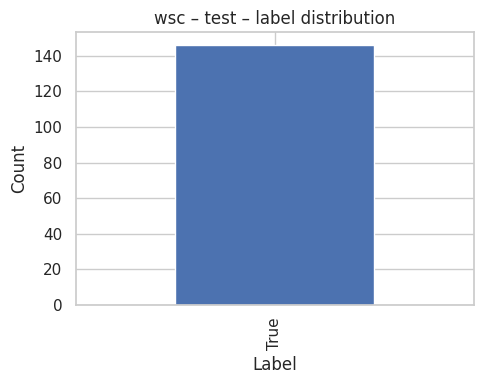

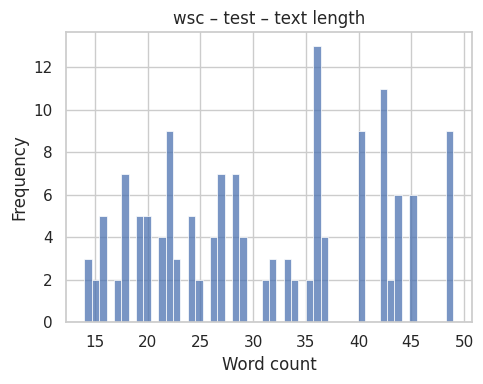

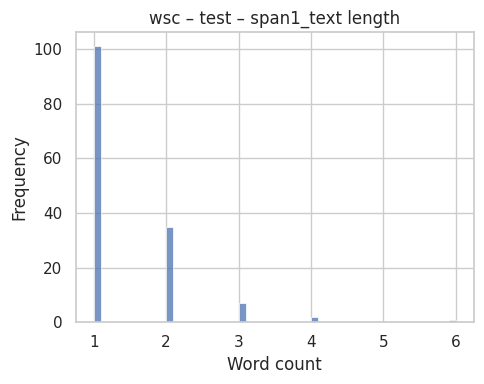

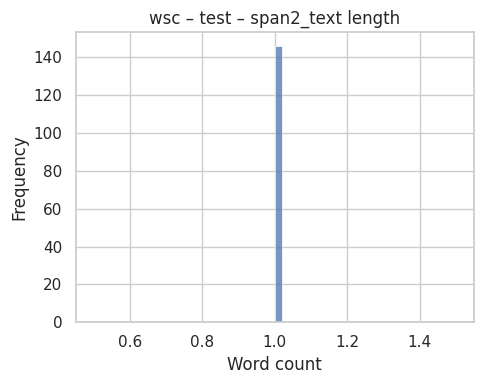

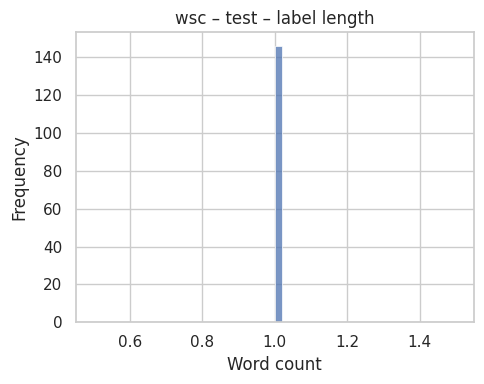


=== AXB ===
axb – test – shape: (1104, 4)


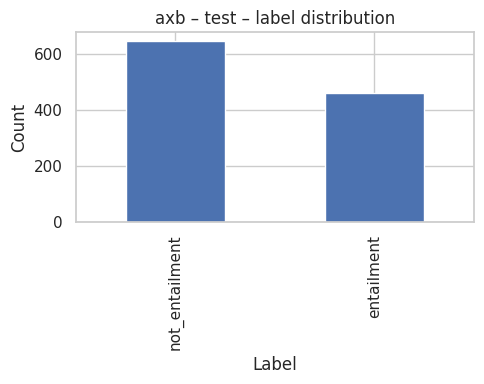

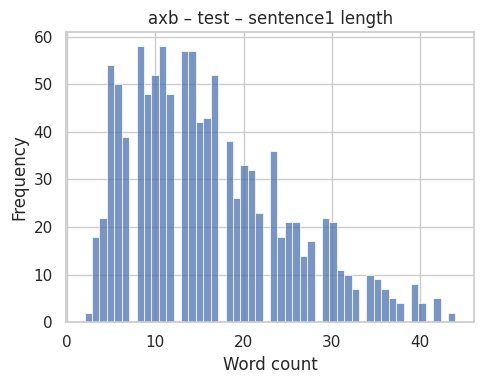

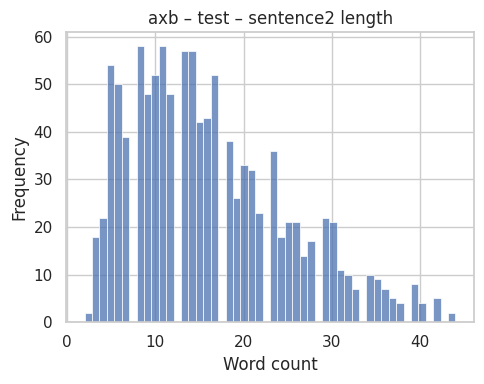

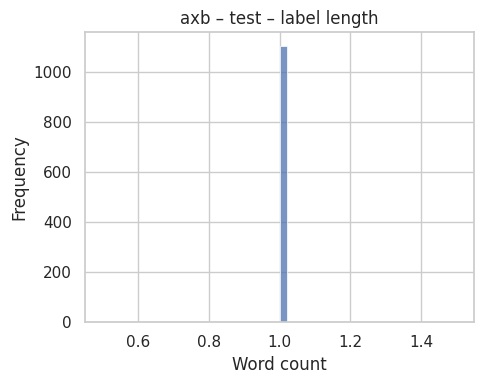


=== AXG ===
axg – test – shape: (356, 4)


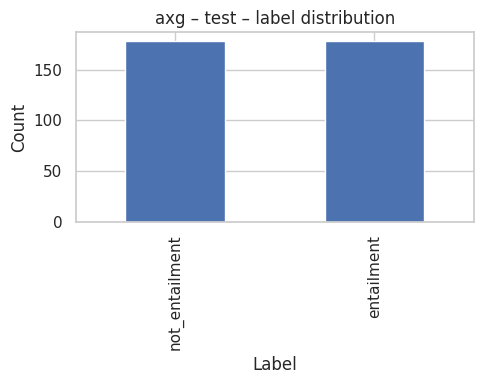

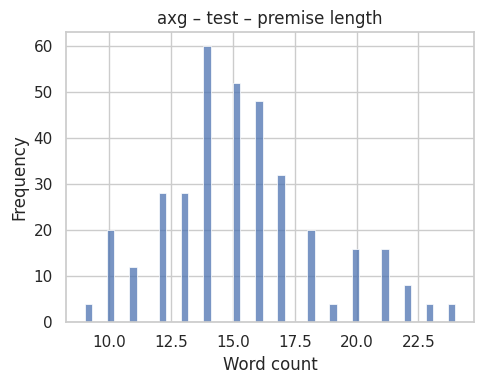

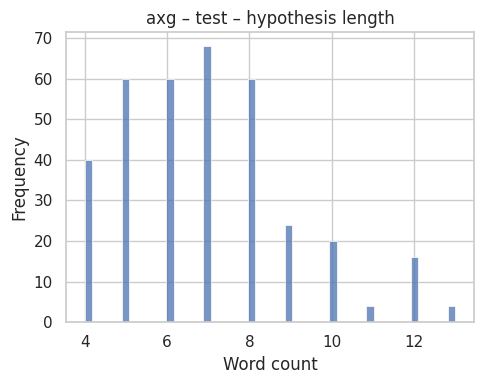

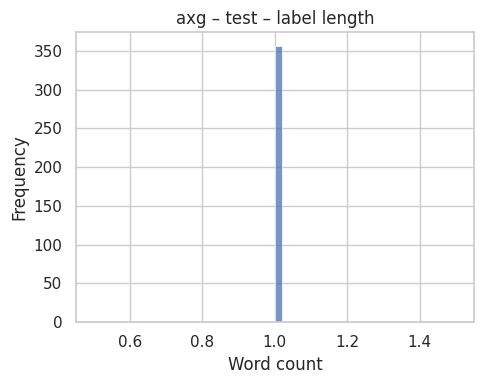

In [ ]:
plot_dataset_sizes(all_dfs)

for task, splits in all_dfs.items():
    print(f"\n=== {task.upper()} ===")
    for split, df in splits.items():
        print(f"{task} – {split} – shape: {df.shape}")
        plot_label_distribution(df, task, split)
        plot_text_length_histograms(df, task, split)

In [ ]:
def build_size_df(all_dfs):
    rows = []
    for task, splits in all_dfs.items():
        for split, df in splits.items():
            rows.append({"task": task, "split": split, "n": len(df)})
    return pd.DataFrame(rows)

size_df = build_size_df(all_dfs)
fig_sizes = px.bar(
    size_df,
    x="task",
    y="n",
    color="split",
    barmode="group",
    title="SuperGLUE – dataset sizes (interactive)"
)
fig_sizes.show()

## Interactive text length explorer

In [ ]:
def get_text_cols(df):
    cols = []
    for col in df.columns:
        sample = df[col].dropna().head(50)
        if len(sample) == 0:
            continue
        if sample.apply(lambda x: isinstance(x, str)).mean() > 0.5:
            cols.append(col)
    return cols

task_dropdown = widgets.Dropdown(
    options=sorted(all_dfs.keys()),
    description="Task:",
    value="boolq"
)

split_dropdown = widgets.Dropdown(
    options=[],
    description="Split:"
)

col_dropdown = widgets.Dropdown(
    options=[],
    description="Text col:"
)

def update_splits(*args):
    splits = list(all_dfs[task_dropdown.value].keys())
    split_dropdown.options = splits
    split_dropdown.value = splits[0]

def update_cols(*args):
    df = all_dfs[task_dropdown.value][split_dropdown.value]
    cols = get_text_cols(df)
    if cols:
        col_dropdown.options = cols
        col_dropdown.value = cols[0]
    else:
        col_dropdown.options = []
        col_dropdown.value = None

def update_plot(*args):
    if not col_dropdown.value:
        return
    df = all_dfs[task_dropdown.value][split_dropdown.value]
    lengths = df[col_dropdown.value].astype(str).str.split().str.len()
    fig = px.histogram(
        lengths,
        nbins=60,
        title=f"{task_dropdown.value} – {split_dropdown.value} – {col_dropdown.value} length"
    )
    fig.update_xaxes(title="Word count")
    fig.update_yaxes(title="Frequency")
    fig.show()

task_dropdown.observe(update_splits, names="value")
split_dropdown.observe(update_cols, names="value")
col_dropdown.observe(update_plot, names="value")

update_splits()
update_cols()

display(task_dropdown, split_dropdown, col_dropdown)
update_plot()

Dropdown(description='Task:', index=2, options=('axb', 'axg', 'boolq', 'cb', 'copa', 'multirc', 'record', 'rte…

Dropdown(description='Split:', options=('train', 'validation', 'test'), value='train')

Dropdown(description='Text col:', options=('question', 'passage', 'label'), value='question')